In [1]:
import importlib
from pathlib import Path
from IPython.display import display

try:
    import helpers.elements_3d as e3d
    import helpers.preprocess as prep
    import helpers.postprocess as post
    import helpers.solver as solv
    import helpers.output_writer as ow
    import helpers.plotting_simple as ps
    import helpers.plotting_plotly as pp3d

    importlib.reload(e3d)
    importlib.reload(prep)
    importlib.reload(post)
    importlib.reload(solv)
    importlib.reload(ow)
    importlib.reload(ps)
    importlib.reload(pp3d)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.output_writer import write_run_outputs
    from helpers.plotting_simple import plot_structure_simple
    from helpers.plotting_plotly import plot_structure_plotly

except ImportError:
    import elements_3d as e3d
    import preprocess as prep
    import postprocess as post
    import solver as solv
    import output_writer as ow
    import plotting_simple as ps
    import plotting_plotly as pp3d

    importlib.reload(e3d)
    importlib.reload(prep)
    importlib.reload(post)
    importlib.reload(solv)
    importlib.reload(ow)
    importlib.reload(ps)
    importlib.reload(pp3d)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from output_writer import write_run_outputs
    from plotting_simple import plot_structure_simple
    from plotting_plotly import plot_structure_plotly

model_path = "inputs/final_bridge/scenario_extreme_missing_diagonals_overload.json"

In [2]:
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

print("Model ran successfully")
print()
print("Model name")
print(clean_model["model_name"])
print()
print("Total DOF")
print(data["ndof"])
print()
print("Number of elements")
print(len(clean_model["elements"]))
print()
print("Max absolute displacement")
print(abs(package["results"]["U"]).max())

Model ran successfully

Model name
scenario_extreme_missing_diagonals_overload

Total DOF
234

Number of elements
87

Max absolute displacement
0.0009579744227415707


In [3]:
output_dir, tables, global_summary, dof_summary = write_run_outputs(
    clean_model=clean_model,
    data=data,
    summary=summary,
    package=package,
    model_path=model_path,
    output_root="outputs/runs"
)

print(f"Outputs saved to {output_dir}")
print()
print(list(tables.keys()))

Outputs saved to outputs\runs\scenario_extreme_missing_diagonals_overload

['model_summary', 'nodal_loads', 'node_displacements', 'support_reactions', 'element_basic_data', 'element_local_displacements', 'element_local_end_forces', 'element_global_end_forces', 'element_derived_results']


In [4]:
display(tables["model_summary"])
display(tables["node_displacements"])
display(tables["support_reactions"])
display(tables["element_local_end_forces"])
display(tables["element_derived_results"])

,model_name,length_unit,force_unit,n_nodes,n_elements,n_truss_elements,n_frame_elements,n_free_dofs,n_restrained_dofs,max_displacement_node,max_displacement_magnitude
0,scenario_extreme_missing_diagonals_overload,ft,kip,39,87,55,32,132,102,32,0.000969


,node_id,x,y,z,ux,uy,uz,rx,ry,rz,disp_mag,rot_mag
0,1,0.000,0.0,0.0,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
1,2,18.176,0.0,0.0,0.000037,0.000000e+00,-0.000349,0.000000e+00,0.000000,0.000000e+00,0.000351,0.000000
2,3,36.352,0.0,0.0,0.000068,0.000000e+00,-0.000607,0.000000e+00,0.000000,0.000000e+00,0.000611,0.000000
3,4,54.528,0.0,0.0,0.000143,0.000000e+00,-0.000764,0.000000e+00,0.000000,0.000000e+00,0.000778,0.000000
4,5,72.704,0.0,0.0,0.000219,0.000000e+00,-0.000647,0.000000e+00,0.000000,0.000000e+00,0.000683,0.000000
5,6,90.880,0.0,0.0,0.000256,0.000000e+00,-0.000387,0.000000e+00,0.000000,0.000000e+00,0.000464,0.000000
6,7,109.055,0.0,0.0,0.000300,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000300,0.000000
7,8,18.176,0.0,20.0,0.000256,0.000000e+00,-0.000343,0.000000e+00,0.000000,0.000000e+00,0.000428,0.000000
8,9,36.352,0.0,20.0,0.000203,0.000000e+00,-0.000607,0.000000e+00,0.000000,0.000000e+00,0.000640,0.000000
9,10,54.528,0.0,20.0,0.000150,0.000000e+00,-0.000733,0.000000e+00,0.000000,0.000000e+00,0.000749,0.000000


,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz,reaction_force_mag,reaction_moment_mag
0,1,0.000,0.0,0.0,-0.03196,0.000000,9.405442,0.000000,0.000000,0.000000,9.405496,0.000000
1,2,18.176,0.0,0.0,0.00000,-0.035674,0.000000,5.015837,-0.370133,4.597640,0.035674,6.814243
2,3,36.352,0.0,0.0,0.00000,0.021376,0.000000,13.386226,-0.383097,3.516173,0.021376,13.845623
3,4,54.528,0.0,0.0,0.00000,0.027644,0.000000,25.532895,-0.262549,0.061573,0.027644,25.534319
4,5,72.704,0.0,0.0,0.00000,0.022602,0.000000,25.760812,-0.095024,-3.378936,0.022602,25.981641
5,6,90.880,0.0,0.0,0.00000,-0.035948,0.000000,9.152090,-0.036859,-4.799964,0.035948,10.334494
6,7,109.055,0.0,0.0,0.00000,0.000000,11.117335,0.000000,0.000000,0.000000,11.117335,0.000000
7,8,18.176,0.0,20.0,0.00000,4.029915,0.000000,0.000000,0.000000,0.000000,4.029915,0.000000
8,9,36.352,0.0,20.0,0.00000,8.112123,0.000000,0.000000,0.000000,0.000000,8.112123,0.000000
9,10,54.528,0.0,20.0,0.00000,8.649910,0.000000,0.000000,0.000000,0.000000,8.649910,0.000000


,elem_id,type,node_i,node_j,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,101,3D_truss,1,2,-8.534186,0.0,0.0,0.0,0.0,0.0,8.534186,0.0,0.0,0.0,0.0,0.0
1,102,3D_truss,2,3,-7.158135,0.0,0.0,0.0,0.0,0.0,7.158135,0.0,0.0,0.0,0.0,0.0
2,103,3D_truss,3,4,-17.273060,0.0,0.0,0.0,0.0,0.0,17.273060,0.0,0.0,0.0,0.0,0.0
3,104,3D_truss,4,5,-17.253211,0.0,0.0,0.0,0.0,0.0,17.253211,0.0,0.0,0.0,0.0,0.0
4,105,3D_truss,5,6,-8.617541,0.0,0.0,0.0,0.0,0.0,8.617541,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,509,3D_truss,21,10,5.481061,0.0,0.0,0.0,0.0,0.0,-5.481061,0.0,0.0,0.0,0.0,0.0
83,510,3D_truss,10,23,6.207261,0.0,0.0,0.0,0.0,0.0,-6.207261,0.0,0.0,0.0,0.0,0.0
84,511,3D_truss,22,11,6.208580,0.0,0.0,0.0,0.0,0.0,-6.208580,0.0,0.0,0.0,0.0,0.0
85,512,3D_truss,11,24,6.221053,0.0,0.0,0.0,0.0,0.0,-6.221053,0.0,0.0,0.0,0.0,0.0


,elem_id,type,node_i,node_j,L,axial_i_local,axial_j_local,axial_abs_max,shear_y_abs_max,shear_z_abs_max,torsion_abs_max,moment_y_abs_max,moment_z_abs_max,moment_abs_max,stress_axial_i,stress_axial_j,stress_axial_abs_max
0,101,3D_truss,1,2,18.176000,-8.534186,8.534186,8.534186,0.0,0.0,0.0,0.0,0.0,0.0,-8.534186,8.534186,8.534186
1,102,3D_truss,2,3,18.176000,-7.158135,7.158135,7.158135,0.0,0.0,0.0,0.0,0.0,0.0,-7.158135,7.158135,7.158135
2,103,3D_truss,3,4,18.176000,-17.273060,17.273060,17.273060,0.0,0.0,0.0,0.0,0.0,0.0,-17.273060,17.273060,17.273060
3,104,3D_truss,4,5,18.176000,-17.253211,17.253211,17.253211,0.0,0.0,0.0,0.0,0.0,0.0,-17.253211,17.253211,17.253211
4,105,3D_truss,5,6,18.176000,-8.617541,8.617541,8.617541,0.0,0.0,0.0,0.0,0.0,0.0,-8.617541,8.617541,8.617541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,509,3D_truss,21,10,27.025303,5.481061,-5.481061,5.481061,0.0,0.0,0.0,0.0,0.0,0.0,5.481061,-5.481061,5.481061
83,510,3D_truss,10,23,27.025303,6.207261,-6.207261,6.207261,0.0,0.0,0.0,0.0,0.0,0.0,6.207261,-6.207261,6.207261
84,511,3D_truss,22,11,27.025303,6.208580,-6.208580,6.208580,0.0,0.0,0.0,0.0,0.0,0.0,6.208580,-6.208580,6.208580
85,512,3D_truss,11,24,27.025303,6.221053,-6.221053,6.221053,0.0,0.0,0.0,0.0,0.0,0.0,6.221053,-6.221053,6.221053


In [5]:
plot_dir_simple = Path("outputs/final_bridge/simple_plots")
plot_dir_plotly = Path("outputs/final_bridge/plotly_plots")

plot_dir_simple.mkdir(parents=True, exist_ok=True)
plot_dir_plotly.mkdir(parents=True, exist_ok=True)

simple_undeformed = plot_dir_simple / "scenario_extreme_missing_diagonals_overload_undeformed.png"
simple_def_undef = plot_dir_simple / "scenario_extreme_missing_diagonals_overload_undeformed_plus_deformed.png"

plotly_undef_html = plot_dir_plotly / "scenario_extreme_missing_diagonals_overload_undeformed.html"
plotly_undef_png  = plot_dir_plotly / "scenario_extreme_missing_diagonals_overload_undeformed.png"

plotly_def_html = plot_dir_plotly / "scenario_extreme_missing_diagonals_overload_undeformed_plus_deformed.html"
plotly_def_png  = plot_dir_plotly / "scenario_extreme_missing_diagonals_overload_undeformed_plus_deformed.png"

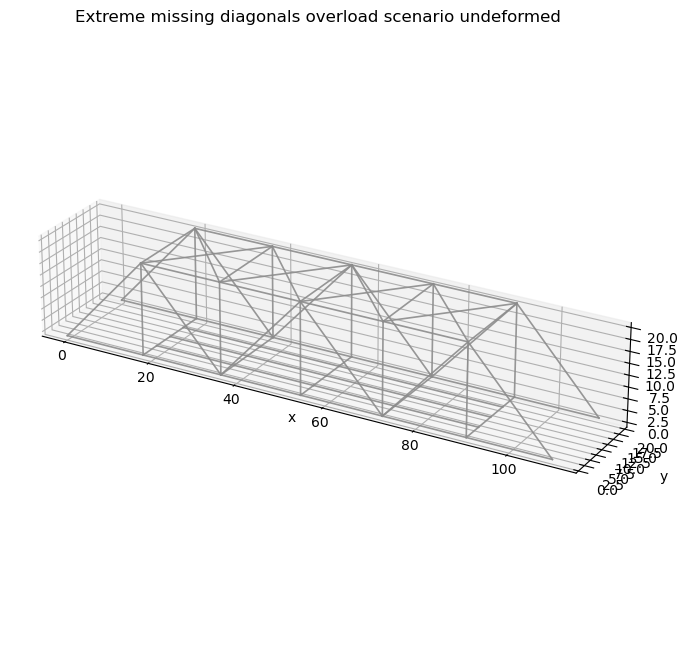

Saved outputs\final_bridge\simple_plots\scenario_extreme_missing_diagonals_overload_undeformed.png


In [6]:
_ = plot_structure_simple(
    clean_model,
    data,
    U=None,
    scale=1.0,
    selector="all",
    show_undeformed=True,
    show_deformed=False,
    show_node_labels=False,
    show_element_labels=False,
    title="Extreme missing diagonals overload scenario undeformed",
    save_path=str(simple_undeformed),
)

print(f"Saved {simple_undeformed}")

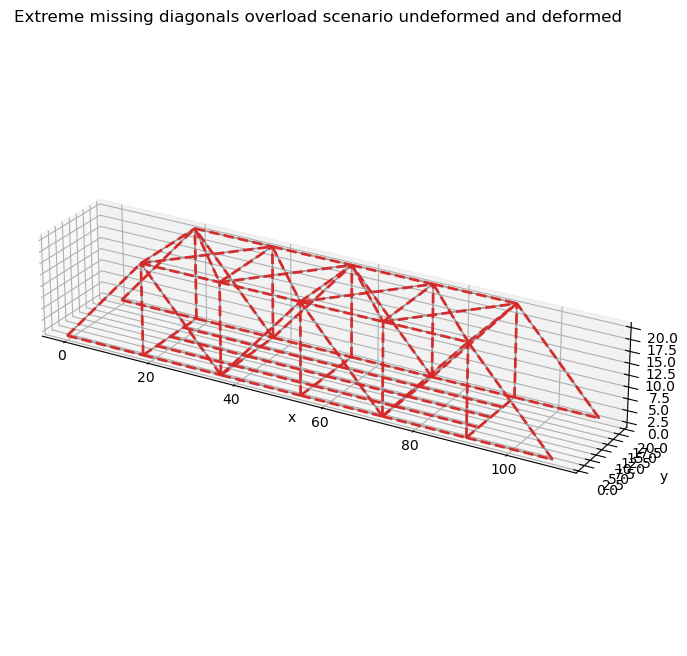

Saved outputs\final_bridge\simple_plots\scenario_extreme_missing_diagonals_overload_undeformed_plus_deformed.png


In [7]:
_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=80.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=False,
    show_element_labels=False,
    title="Extreme missing diagonals overload scenario undeformed and deformed",
    save_path=str(simple_def_undef),
)

print(f"Saved {simple_def_undef}")

In [8]:
fig_undef = plot_structure_plotly(
    clean_model,
    data,
    U=None,
    scale=1.0,
    selector="all",
    show_undeformed=True,
    show_deformed=False,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    show_member_loads=False,
    title="Extreme missing diagonals overload scenario undeformed",
    save_html=str(plotly_undef_html),
    save_png=str(plotly_undef_png),
)

fig_undef.show()

print(f"Saved {plotly_undef_html}")
print(f"Saved {plotly_undef_png}")

Saved outputs\final_bridge\plotly_plots\scenario_extreme_missing_diagonals_overload_undeformed.html
Saved outputs\final_bridge\plotly_plots\scenario_extreme_missing_diagonals_overload_undeformed.png


In [16]:
fig_def = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=8000.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=False,
    show_member_loads=False,
    title="Extreme missing diagonals overload scenario undeformed and deformed",
    save_html=str(plotly_def_html),
    save_png=str(plotly_def_png),
)

fig_def.show()

print(f"Saved {plotly_def_html}")
print(f"Saved {plotly_def_png}")

Saved outputs\final_bridge\plotly_plots\scenario_extreme_missing_diagonals_overload_undeformed_plus_deformed.html
Saved outputs\final_bridge\plotly_plots\scenario_extreme_missing_diagonals_overload_undeformed_plus_deformed.png


In [10]:
import pandas as pd

df_nodes = tables["node_displacements"].copy()

if "disp_mag" in df_nodes.columns:
    df_max_disp = df_nodes.sort_values("disp_mag", ascending=False)[
        ["node_id", "x", "y", "z", "ux", "uy", "uz", "disp_mag"]
    ].head(12)
else:
    df_nodes["disp_mag_calc"] = (df_nodes["ux"]**2 + df_nodes["uy"]**2 + df_nodes["uz"]**2) ** 0.5
    df_max_disp = df_nodes.sort_values("disp_mag_calc", ascending=False)[
        ["node_id", "x", "y", "z", "ux", "uy", "uz", "disp_mag_calc"]
    ].head(12)

display(df_max_disp)

,node_id,x,y,z,ux,uy,uz,disp_mag
31,32,54.528,10.0,0.0,0.000145,1.348417e-10,-0.000958,0.000969
32,33,54.528,15.0,0.0,0.000145,5.543371e-08,-0.000878,0.000890
30,31,54.528,5.0,0.0,0.000145,-5.516380e-08,-0.000876,0.000888
34,35,72.704,10.0,0.0,0.000134,1.288118e-10,-0.000842,0.000853
15,16,54.528,20.0,0.0,0.000144,0.000000e+00,-0.000767,0.000780
35,36,72.704,15.0,0.0,0.000158,4.536140e-08,-0.000761,0.000778
3,4,54.528,0.0,0.0,0.000143,0.000000e+00,-0.000764,0.000778
33,34,72.704,5.0,0.0,0.000158,-4.510332e-08,-0.000760,0.000776
21,22,54.528,20.0,20.0,0.000150,0.000000e+00,-0.000736,0.000751
9,10,54.528,0.0,20.0,0.000150,0.000000e+00,-0.000733,0.000749


In [11]:
df_react = tables["support_reactions"].copy()
display(df_react[["node_id", "x", "y", "z", "Rx", "Ry", "Rz", "Mx", "My", "Mz"]])

,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz
0,1,0.000,0.0,0.0,-0.03196,0.000000,9.405442,0.000000,0.000000,0.000000
1,2,18.176,0.0,0.0,0.00000,-0.035674,0.000000,5.015837,-0.370133,4.597640
2,3,36.352,0.0,0.0,0.00000,0.021376,0.000000,13.386226,-0.383097,3.516173
3,4,54.528,0.0,0.0,0.00000,0.027644,0.000000,25.532895,-0.262549,0.061573
4,5,72.704,0.0,0.0,0.00000,0.022602,0.000000,25.760812,-0.095024,-3.378936
5,6,90.880,0.0,0.0,0.00000,-0.035948,0.000000,9.152090,-0.036859,-4.799964
6,7,109.055,0.0,0.0,0.00000,0.000000,11.117335,0.000000,0.000000,0.000000
7,8,18.176,0.0,20.0,0.00000,4.029915,0.000000,0.000000,0.000000,0.000000
8,9,36.352,0.0,20.0,0.00000,8.112123,0.000000,0.000000,0.000000,0.000000
9,10,54.528,0.0,20.0,0.00000,8.649910,0.000000,0.000000,0.000000,0.000000


In [12]:
df_local = tables["element_local_end_forces"].copy()
df_frame = df_local[df_local["type"] == "3D_frame"].copy()

df_frame["max_abs_end_moment"] = df_frame[
    ["Mx_i_local", "My_i_local", "Mz_i_local", "Mx_j_local", "My_j_local", "Mz_j_local"]
].abs().max(axis=1)

display(df_frame.sort_values("max_abs_end_moment", ascending=False).head(12))

,elem_id,type,node_i,node_j,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local,max_abs_end_moment
54,313,3D_frame,5,34,0.022602,-1.060291,6.426825,-0.095024,-25.760812,-3.378936,-0.022602,1.060291,-6.326825,0.095024,-6.206647,-1.922519,25.760812
57,316,3D_frame,36,17,0.022732,1.063200,-6.347620,0.094818,6.269390,1.927075,-0.022732,-1.063200,6.447620,-0.094818,25.635374,3.388927,25.635374
50,309,3D_frame,4,31,0.027644,0.019848,6.365699,-0.262549,-25.532895,0.061573,-0.027644,-0.019848,-6.265699,0.262549,-6.128933,0.037669,25.532895
53,312,3D_frame,33,16,0.027779,-0.020038,-6.284585,0.262557,6.200447,-0.039093,-0.027779,0.020038,6.384585,-0.262557,25.389146,-0.061097,25.389146
46,305,3D_frame,3,28,0.021376,1.105173,3.456806,-0.383097,-13.386226,3.516173,-0.021376,-1.105173,-3.356806,0.383097,-3.731138,2.009692,13.386226
49,308,3D_frame,30,15,0.021433,-1.108499,-3.377885,0.383336,3.792361,-2.017102,-0.021433,1.108499,3.477885,-0.383336,13.263731,-3.525395,13.263731
55,314,3D_frame,34,35,-0.022667,0.105990,1.443361,-0.086892,6.189275,0.994306,0.022667,-0.105990,-1.343361,0.086892,-13.239414,-0.464358,13.239414
56,315,3D_frame,35,36,-0.022667,-0.106154,-1.364140,0.087098,13.239412,0.464417,0.022667,0.106154,1.464140,-0.087098,-6.252047,-0.995187,13.239412
51,310,3D_frame,31,32,-0.027711,-0.004146,1.438966,-0.109144,6.116186,-0.021183,0.027711,0.004146,-1.338966,0.109144,-13.144351,0.000455,13.144351
52,311,3D_frame,32,33,-0.027711,0.004697,-1.357980,0.109137,13.144346,-0.000393,0.027711,-0.004697,1.457980,-0.109137,-6.187778,0.023878,13.144346


In [13]:
df_derived = tables["element_derived_results"].copy()

if "axial_force" in df_derived.columns:
    df_truss = df_derived[df_derived["type"] == "3D_truss"].copy()
    df_truss["abs_axial"] = df_truss["axial_force"].abs()
    display(df_truss.sort_values("abs_axial", ascending=False).head(12))
else:
    print("No axial_force column found in element_derived_results")

No axial_force column found in element_derived_results


In [14]:
print("Simple plots")
for p in sorted(plot_dir_simple.iterdir()):
    print(p)

print()
print("Plotly plots")
for p in sorted(plot_dir_plotly.iterdir()):
    print(p)

print()
print("Run output files")
for p in sorted(Path(output_dir).iterdir()):
    print(p.name)

Simple plots
outputs\final_bridge\simple_plots\fort_griffin_revised_baseline_undeformed.png
outputs\final_bridge\simple_plots\fort_griffin_revised_baseline_undeformed_plus_deformed.png
outputs\final_bridge\simple_plots\fort_griffin_revised_deadload_undeformed.png
outputs\final_bridge\simple_plots\fort_griffin_revised_deadload_undeformed_plus_deformed.png
outputs\final_bridge\simple_plots\scenario_extreme_missing_diagonals_overload_undeformed.png
outputs\final_bridge\simple_plots\scenario_extreme_missing_diagonals_overload_undeformed_plus_deformed.png

Plotly plots
outputs\final_bridge\plotly_plots\final_01_baseline_full_bridge.html
outputs\final_bridge\plotly_plots\final_01_baseline_full_bridge.png
outputs\final_bridge\plotly_plots\final_02_baseline_floor_system_loads.html
outputs\final_bridge\plotly_plots\final_02_baseline_floor_system_loads.png
outputs\final_bridge\plotly_plots\final_03_missing_diagonal_full_bridge.html
outputs\final_bridge\plotly_plots\final_03_missing_diagonal_full